Read 100 pseudo-C_ell realisations from mock_catalogues.fits
Bandpowers: 9
ell range: 2.5 -- 298.5
Theory ell range: 2 -- 383


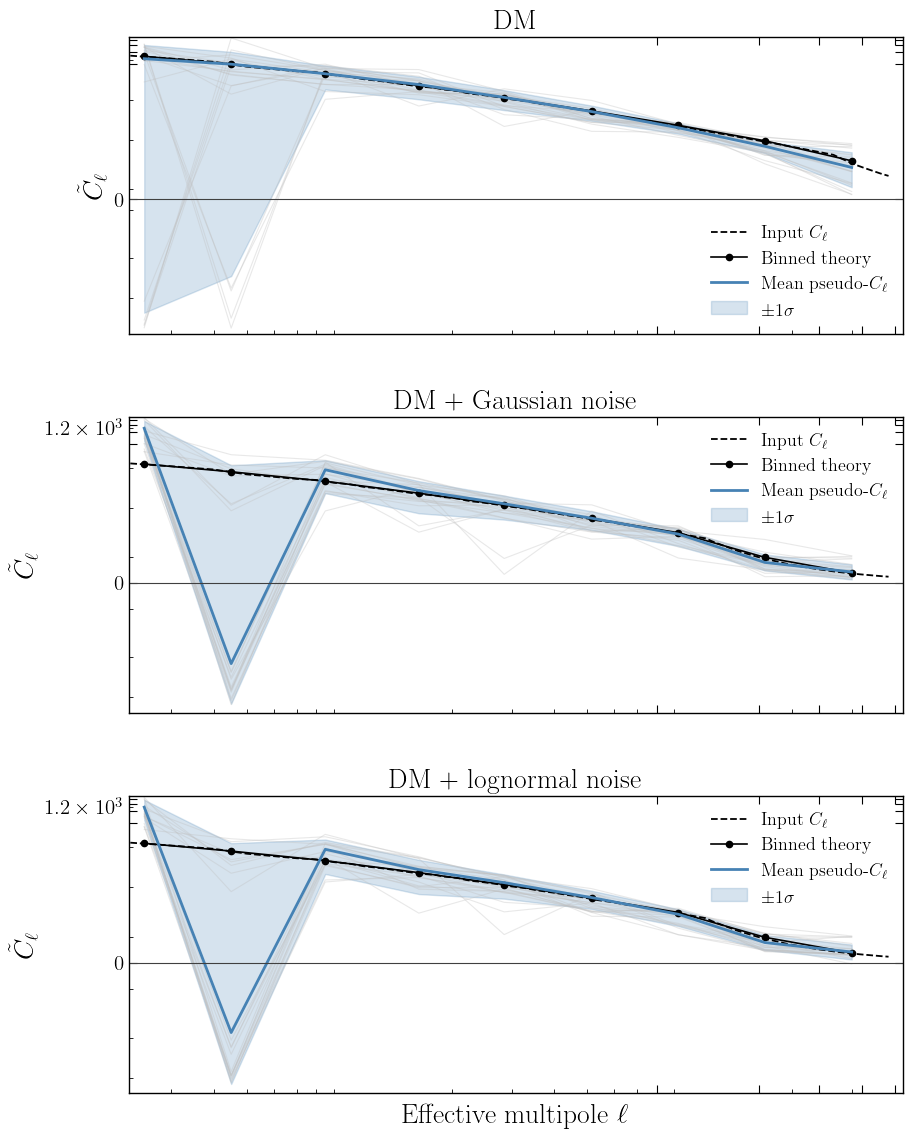

In [3]:
from pathlib import Path
import shutil

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from astropy.io import fits

fits_path = Path("/Users/robert/Documents/Git/pseudo_catcell_covariance_benchmark/output/chime/mock_catalogues.fits")

fontsi = 15
fontsi2 = 20
plt.rcdefaults()
if shutil.which("latex") is not None:
    plt.rc("text", usetex=True)
    plt.rcParams["font.serif"] = ["Computer Modern"]
plt.rc("font", family="serif")
plt.rcParams.update({
    "font.size": fontsi,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

with fits.open(fits_path) as hdul:
    pcl_names = sorted(hdu.name for hdu in hdul if hdu.name.startswith("PCL_"))
    if not pcl_names:
        raise ValueError(f"No PCL_* extensions found in {fits_path}")
    if "CELL" not in hdul:
        raise ValueError(f"No CELL extension found in {fits_path}")

    pcl_header = hdul[pcl_names[0]].header
    pcl_tables = [hdul[name].data for name in pcl_names]
    cell_table = hdul["CELL"].data

ell_eff = np.asarray(pcl_tables[0]["ell_eff"], dtype=float)
pcl_dm = np.vstack([np.asarray(tab["pcl_dm"], dtype=float) for tab in pcl_tables])
pcl_dm_gaussian = np.vstack([np.asarray(tab["pcl_dm_gaussian"], dtype=float) for tab in pcl_tables])
pcl_dm_lognormal = np.vstack([np.asarray(tab["pcl_dm_lognormal"], dtype=float) for tab in pcl_tables])

theory_ell = np.asarray(cell_table["ell"], dtype=float)
theory_cl = np.asarray(cell_table["cell"], dtype=float)
valid_theory = np.isfinite(theory_ell) & np.isfinite(theory_cl) & (theory_ell >= 2)
theory_ell = theory_ell[valid_theory]
theory_cl = theory_cl[valid_theory]

pcl_lmin = int(pcl_header.get("LMIN", max(2, np.floor(ell_eff.min()))))
pcl_lmax = int(pcl_header.get("LMAX", np.ceil(ell_eff.max())))
pcl_nbin = int(pcl_header.get("NBIN", len(ell_eff)))
pcl_edges = np.rint(np.geomspace(pcl_lmin, pcl_lmax + 1, pcl_nbin + 1)).astype(int)
pcl_edges[0] = pcl_lmin
pcl_edges[-1] = pcl_lmax + 1
pcl_edges = np.unique(pcl_edges)

if len(pcl_edges) - 1 == len(ell_eff):
    theory_binned = np.full(len(ell_eff), np.nan, dtype=float)
    for index, (ell_lo, ell_hi) in enumerate(zip(pcl_edges[:-1], pcl_edges[1:])):
        in_bin = (theory_ell >= ell_lo) & (theory_ell < ell_hi)
        if np.any(in_bin):
            theory_binned[index] = np.mean(theory_cl[in_bin])
else:
    theory_binned = np.interp(ell_eff, theory_ell, theory_cl, left=np.nan, right=np.nan)

series = {
    "DM": pcl_dm,
    "DM + Gaussian noise": pcl_dm_gaussian,
    "DM + lognormal noise": pcl_dm_lognormal,
}

print(f"Read {len(pcl_names)} pseudo-C_ell realisations from {fits_path.name}")
print(f"Bandpowers: {len(ell_eff)}")
print(f"ell range: {ell_eff.min():.1f} -- {ell_eff.max():.1f}")
print(f"Theory ell range: {theory_ell.min():.0f} -- {theory_ell.max():.0f}")

fig, axes = plt.subplots(3, 1, figsize=(9.0, 12.0), sharex=True)

for ax, (label, values) in zip(axes, series.items()):
    mean = np.nanmean(values, axis=0)
    std = np.nanstd(values, axis=0)
    n_show = min(20, len(values))

    for row in values[:n_show]:
        ax.plot(ell_eff, row, color="0.75", lw=0.8, alpha=0.35)

    ax.plot(theory_ell, theory_cl, color="black", lw=1.3, ls="--", label=r"Input $C_\ell$")
    ax.plot(ell_eff, theory_binned, color="black", marker="o", ms=4.5, lw=1.2, label=r"Binned theory")
    ax.plot(ell_eff, mean, color="steelblue", lw=2.0, label=r"Mean pseudo-$C_\ell$")
    ax.fill_between(ell_eff, mean - std, mean + std, color="steelblue", alpha=0.22, label=r"$\pm 1\sigma$")
    ax.axhline(0.0, color="0.25", lw=0.8)

    y_stack = np.concatenate([
        values[np.isfinite(values)],
        mean[np.isfinite(mean)],
        theory_binned[np.isfinite(theory_binned)],
        theory_cl[np.isfinite(theory_cl)],
    ])
    y_abs_max = np.nanmax(np.abs(y_stack)) if y_stack.size else 1.0
    linthresh = max(1e-8, 5e-4 * y_abs_max)

    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=linthresh)
    ax.set_xlim(max(2.0, 0.9 * ell_eff.min()), 1.1 * max(ell_eff.max(), theory_ell.max()))
    ax.set_ylabel(r"$\tilde{C}_\ell$", fontsize=fontsi2)
    ax.set_title(label, fontsize=fontsi2)
    ax.tick_params(labelsize=fontsi, top=True, right=True)
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.legend(fontsize=fontsi - 2, frameon=False, loc="best")

axes[-1].set_xlabel(r"Effective multipole $\ell$", fontsize=fontsi2)
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.08, top=0.96, hspace=0.28)
plt.show()

Computed covariance and correlation matrices:
  DM: shape = (9, 9)
  DM + Gaussian noise: shape = (9, 9)
  DM + lognormal noise: shape = (9, 9)


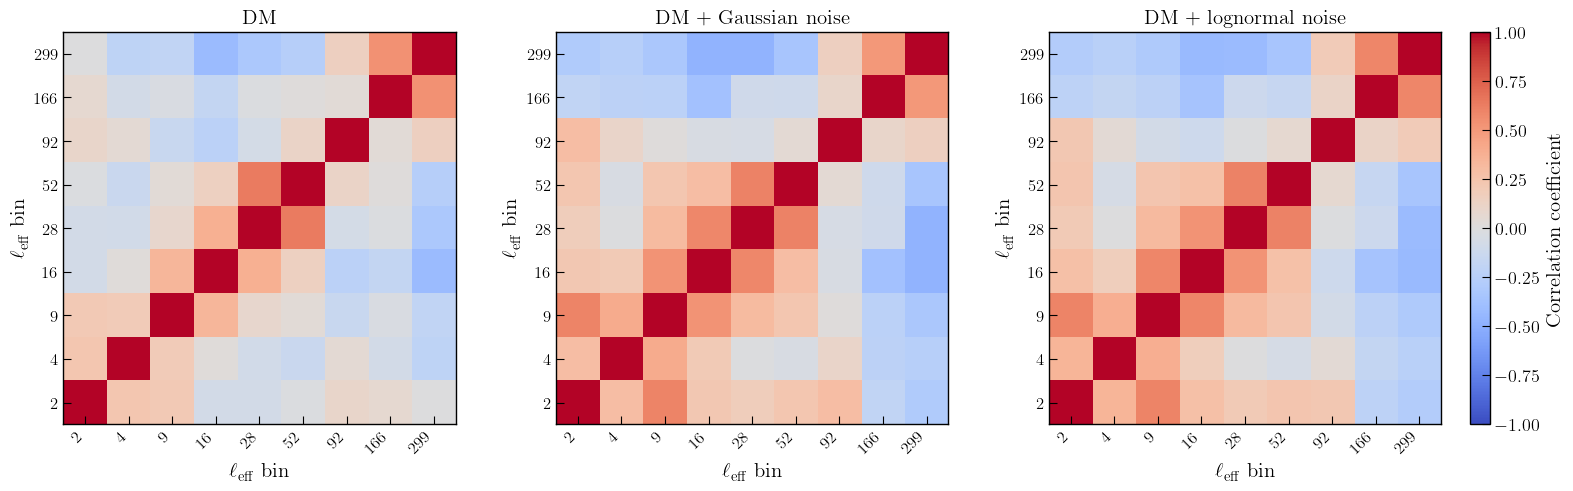

In [4]:
# Covariance and correlation-coefficient matrices for the three pseudo-C_ell cases
# Requires Cell 1 to have defined: ell_eff and series
if "series" not in globals() or "ell_eff" not in globals():
    raise ValueError("Run Cell 1 first so 'series' and 'ell_eff' are defined.")

covariance_mats = {}
correlation_mats = {}

for label, values in series.items():
    arr = np.asarray(values, dtype=float)
    cov = np.cov(arr, rowvar=False, ddof=1)
    sigma = np.sqrt(np.diag(cov))
    denom = np.outer(sigma, sigma)
    corr = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)

    covariance_mats[label] = cov
    correlation_mats[label] = corr

print("Computed covariance and correlation matrices:")
for label in series:
    print(f"  {label}: shape = {covariance_mats[label].shape}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, (label, corr) in zip(axes, correlation_mats.items()):
    im = ax.imshow(
        corr,
        origin="lower",
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
        interpolation="nearest",
    )
    ax.set_title(label, fontsize=fontsi)

    tick_idx = np.arange(len(ell_eff))
    tick_labels = [f"{int(np.rint(x))}" for x in ell_eff]
    ax.set_xticks(tick_idx)
    ax.set_yticks(tick_idx)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=fontsi - 3)
    ax.set_yticklabels(tick_labels, fontsize=fontsi - 3)
    ax.set_xlabel(r"$\ell_{\rm eff}$ bin", fontsize=fontsi)
    ax.set_ylabel(r"$\ell_{\rm eff}$ bin", fontsize=fontsi)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label("Correlation coefficient", fontsize=fontsi)
cbar.ax.tick_params(labelsize=fontsi - 2)

plt.show()